# Sentinel-2 Atmospheric Correction and NDVI

This notebook will automatically install the necessary packages (`Py6S`, `geemap`, `gee-atmcorr-S2`) if they are not present, authenticate with Earth Engine, perform atmospheric correction, and output the NDVI JPG and corrected TIF directly to your local folder.

In [7]:
import os
import sys

# Auto-install Py6S, geemap and clone gee-atmcorr-S2 if missing
try:
    from Py6S import *
    import geemap
except ImportError:
    print('Py6S or geemap not found. Installing via conda-forge...')
    get_ipython().system('conda install -y -c conda-forge py6s geemap')
    from Py6S import *
    import geemap

if not os.path.exists('gee-atmcorr-S2'):
    print('gee-atmcorr-S2 not found. Cloning repository...')
    get_ipython().system('git clone https://github.com/samsammurphy/gee-atmcorr-S2')

sys.path.append(os.path.join(os.getcwd(), 'gee-atmcorr-S2', 'bin'))
from atmospheric import Atmospheric
print('Dependencies loaded successfully.')

Dependencies loaded successfully.


In [8]:
import ee
import datetime
import math
from IPython.display import display, Image, HTML
import urllib.request

try:
    ee.Initialize(project='spatialgeography')
except ee.EEException:
    print('Authenticating Earth Engine...')
    ee.Authenticate()
    ee.Initialize(project='spatialgeography')

In [9]:
# Study area for May 2016
coords = [[[85.72645068492152, 19.84985784482506],
           [85.72645068492152, 19.77330631606842],
           [85.91630816783167, 19.77330631606842],
           [85.91630816783167, 19.84985784482506]]]
geom = ee.Geometry.Polygon(coords)

# Specific Sentinel-2 HARMONIZED image
S2 = ee.Image('COPERNICUS/S2_HARMONIZED/20160503T044702_20160503T045815_T45QUB')
toa = S2.divide(10000)

info = S2.getInfo()['properties']
scene_date = datetime.datetime.utcfromtimestamp(info['system:time_start']/1000)
solar_z = info['MEAN_SOLAR_ZENITH_ANGLE']
date = ee.Date(scene_date.strftime("%Y-%m-%d"))

# Extract Atmospheric Parameters
h2o = Atmospheric.water(geom, date).getInfo()
o3 = Atmospheric.ozone(geom, date).getInfo()
aot = Atmospheric.aerosol(geom, date).getInfo()

SRTM = ee.Image('CGIAR/SRTM90_V4')
alt = SRTM.reduceRegion(reducer = ee.Reducer.mean(), geometry = geom.centroid(1)).get('elevation').getInfo()
km = alt/1000

print('Parameters calculated successfully.')

C:\Users\pulak\AppData\Local\Temp\ipykernel_64396\489356860.py:13: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  scene_date = datetime.datetime.utcfromtimestamp(info['system:time_start']/1000)


Parameters calculated successfully.


In [10]:
s = SixS()
s.atmos_profile = AtmosProfile.UserWaterAndOzone(h2o,o3)
s.aero_profile = AeroProfile.Continental
s.aot550 = aot

s.geometry = Geometry.User()
s.geometry.view_z = 0               
s.geometry.solar_z = solar_z        
s.geometry.month = scene_date.month 
s.geometry.day = scene_date.day     
s.altitudes.set_sensor_satellite_level()
s.altitudes.set_target_custom_altitude(km)

def spectralResponseFunction(bandname):
    bandSelect = {
        'B1':PredefinedWavelengths.S2A_MSI_01,
        'B2':PredefinedWavelengths.S2A_MSI_02,
        'B3':PredefinedWavelengths.S2A_MSI_03,
        'B4':PredefinedWavelengths.S2A_MSI_04,
        'B5':PredefinedWavelengths.S2A_MSI_05,
        'B6':PredefinedWavelengths.S2A_MSI_06,
        'B7':PredefinedWavelengths.S2A_MSI_07,
        'B8':PredefinedWavelengths.S2A_MSI_08,
        'B8A':PredefinedWavelengths.S2A_MSI_8A,
        'B9':PredefinedWavelengths.S2A_MSI_09,
        'B10':PredefinedWavelengths.S2A_MSI_10,
        'B11':PredefinedWavelengths.S2A_MSI_11,
        'B12':PredefinedWavelengths.S2A_MSI_12,
        }
    return Wavelength(bandSelect[bandname])

def toa_to_rad(bandname):
    ESUN = info['SOLAR_IRRADIANCE_'+bandname]
    solar_angle_correction = math.cos(math.radians(solar_z))
    doy = scene_date.timetuple().tm_yday
    d = 1 - 0.01672 * math.cos(0.9856 * (doy-4)) 
    multiplier = ESUN*solar_angle_correction/(math.pi*d**2)
    rad = toa.select(bandname).multiply(multiplier)
    return rad

def surface_reflectance(bandname):
    s.wavelength = spectralResponseFunction(bandname)
    s.run()
    Edir = s.outputs.direct_solar_irradiance             
    Edif = s.outputs.diffuse_solar_irradiance            
    Lp   = s.outputs.atmospheric_intrinsic_radiance      
    absorb  = s.outputs.trans['global_gas'].upward       
    scatter = s.outputs.trans['total_scattering'].upward 
    tau2 = absorb*scatter                                
    rad = toa_to_rad(bandname)
    ref = rad.subtract(Lp).multiply(math.pi).divide(tau2*(Edir+Edif))
    return ref

b = surface_reflectance('B2')
g = surface_reflectance('B3')
r = surface_reflectance('B4')
nir = surface_reflectance('B8')
ref = r.addBands(g).addBands(b).addBands(nir)

# Calculate NDVI
ndvi = ref.normalizedDifference(['B8', 'B4']).rename('NDVI')

In [11]:
# Set properties for export
dateString = scene_date.strftime("%Y-%m-%d")
ref = ref.set({'satellite':'Sentinel 2',
              'fileID':info['system:index'],
              'date':dateString,
              'aerosol_optical_thickness':aot,
              'water_vapour':h2o,
              'ozone':o3})

assetID = 'projects/spatialgeography/assets/sentinel2_atmcorr_export_' + dateString + '_HARMONIZED'
print("Starting export to Asset:", assetID)

export_asset = ee.batch.Export.image.toAsset(
    image=ref,
    description='sentinel2_atmcorr_export_'+dateString+'_HARMONIZED_Asset',
    assetId=assetID,
    region=geom,
    scale=10,
    maxPixels=1e13
)
export_asset.start()

print("Downloading Corrected TIF Locally using geemap...")
# Export to local TIF file directly
out_tif = 'sentinel2_corrected_' + dateString + '.tif'
geemap.ee_export_image(ref, filename=out_tif, scale=10, region=geom, file_per_band=False)
print(f"Saved Corrected TIF to: {out_tif}")

Starting export to Asset: projects/spatialgeography/assets/sentinel2_atmcorr_export_2016-05-03_HARMONIZED
Generating URL ...
An error occurred while downloading.
Total request size (61980660 bytes) must be less than or equal to 50331648 bytes.
Saved Corrected TIF to: sentinel2_corrected_2016-05-03.tif


NDVI Image URL: https://earthengine.googleapis.com/v1/projects/spatialgeography/thumbnails/002935b4af3bdd38debea9c2965ee3b4-bc6f3e81974f0876e939fc34a98a5180:getPixels
Saved NDVI Image to: sentinel2_ndvi_2016-05-03.jpg


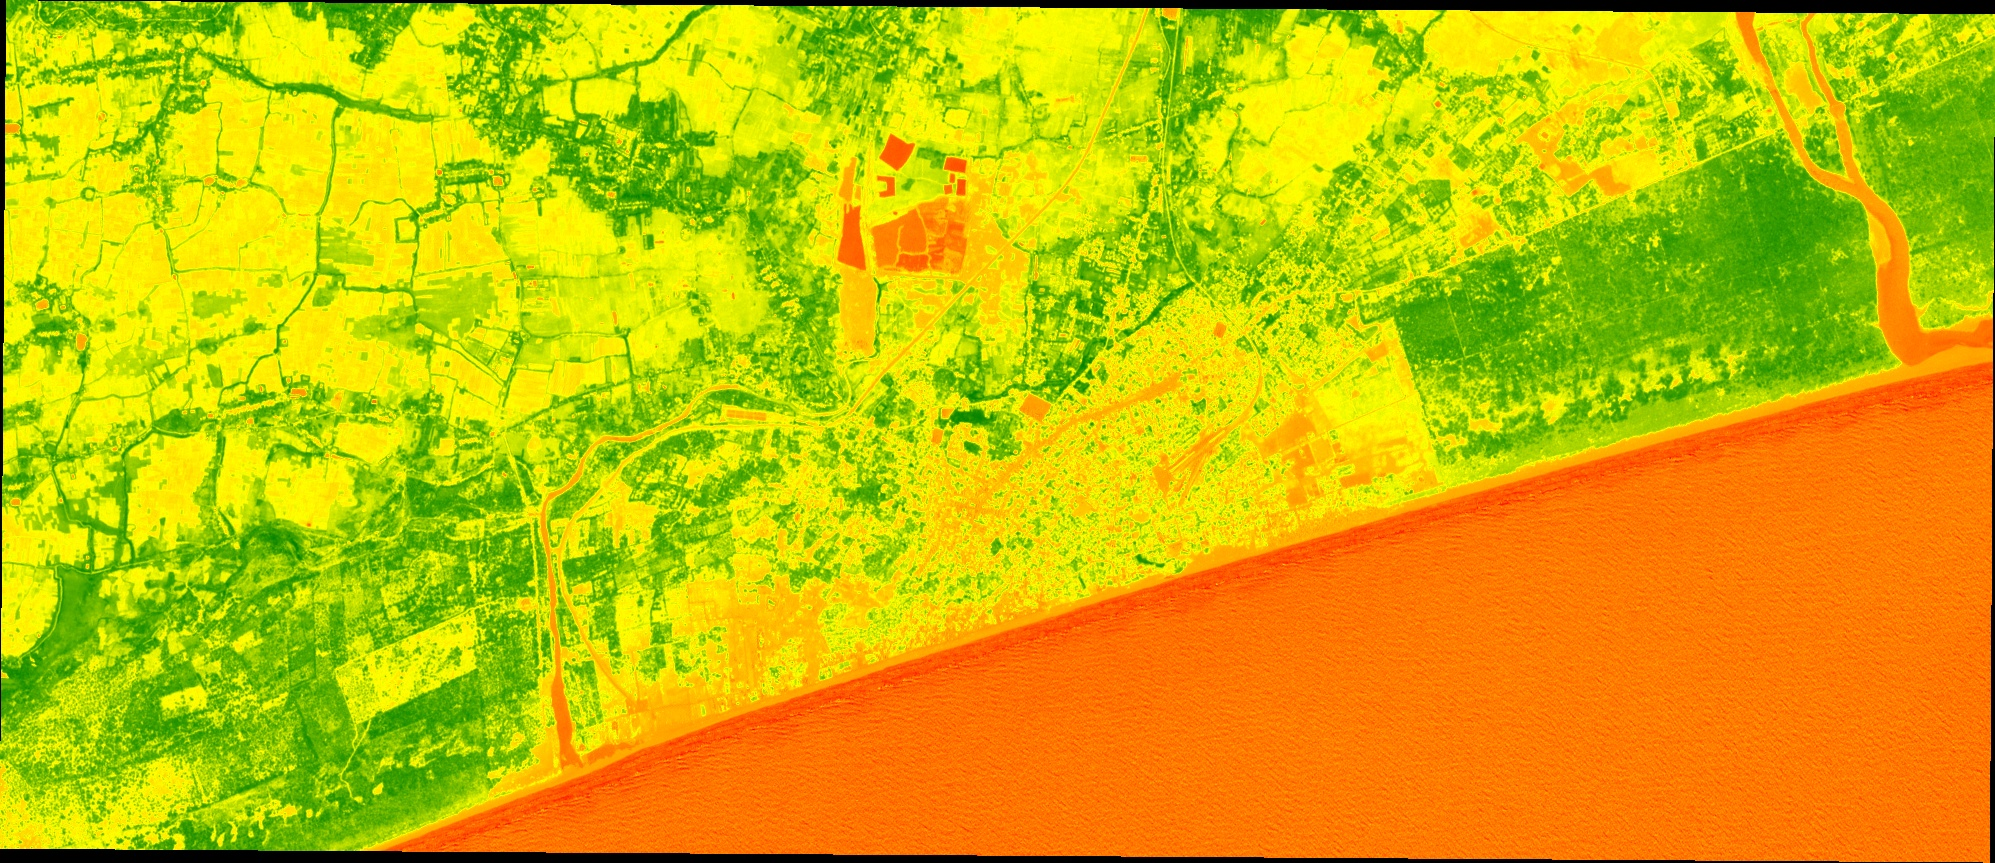

In [12]:
# Download and Display NDVI JPG
region = geom.bounds().getInfo()['coordinates']

ndvi_url = ndvi.getThumbUrl({
    'region': region,
    'min': -0.2,
    'max': 0.8,
    'palette': ['red', 'yellow', 'green'],
    'format': 'jpg'
})

print("NDVI Image URL:", ndvi_url)
out_jpg = 'sentinel2_ndvi_' + dateString + '.jpg'
urllib.request.urlretrieve(ndvi_url, out_jpg)
print(f"Saved NDVI Image to: {out_jpg}")

display(Image(out_jpg))